# 🛡️ Généralisation — Simulation d'impact en cascade sur graphe de connaissance

**Cadre :** Deliverable 2 — Marine Nationale.

**Énoncé (extrait `README.md`) :**
> *Généraliser les traitements réalisés précédemment sur graphe de connaissance, simuler de manière automatisée l'impact en cascade d'une panne ou d'une cyberattaque, identifier les processus métier affectés, produire un tableau de bord interactif.*

## Plan du notebook
1. **Chargement & cartographie** du graphe (10 000 actifs IT, 1 000 attaques, 2 000 événements, 20 000 dépendances).
2. **Analyse topologique** — centralités, hubs critiques.
3. **Moteur de simulation de cascade** — fonction générique `simulate_cascade(seed, depth, threshold)`.
4. **Pont actif → processus métier — DEUX stratégies interchangeables :**
   - 4a · Mapping **par hash** (déterministe, neutre) — *baseline reproductible*.
   - 4b · Mapping **sémantique** par mots-clefs d'événements — *exploite le signal métier*.
   - 4c · Comparaison côte-à-côte des deux stratégies.
5. **Visualisation du graphe de cascade** — réseau Plotly coloré par sévérité.
6. **Tableau de bord interactif** avec :
   - choix d'attaque, profondeur, seuil ;
   - **commutateur de stratégie de mapping** ;
   - **curseur temporel** rejouant les événements chronologiquement.

## 0 · Imports & chargement

In [66]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import hashlib, re
from pathlib import Path
from collections import defaultdict, Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 30)

DATA = Path("generalisation")

attacks      = pd.read_csv(DATA / "nodes_attacks_final.csv")
events       = pd.read_csv(DATA / "nodes_events_final.csv", parse_dates=["timestamp"])
processes    = pd.read_csv(DATA / "processes_final.csv")
dependencies = pd.read_csv(DATA / "rels_dependencies_final.csv")
generated    = pd.read_csv(DATA / "rels_generated_final.csv")
targets      = pd.read_csv(DATA / "rels_targets_final.csv")

assets = pd.DataFrame({"asset_id": sorted(set(dependencies["source"]) |
                                            set(dependencies["target"]) |
                                            set(targets["target"]))})

print(f"Attaques     : {len(attacks):>6}")
print(f"Événements   : {len(events):>6}")
print(f"Processus    : {len(processes):>6}")
print(f"Dépendances  : {len(dependencies):>6}")
print(f"Generates    : {len(generated):>6}")
print(f"Targets      : {len(targets):>6}")
print(f"Actifs uniqs : {len(assets):>6}")

Attaques     :   1000
Événements   :   2000
Processus    :     15
Dépendances  :  20000
Generates    :   2000
Targets      :   3000
Actifs uniqs :   9855


## 1 · Cartographie du graphe

In [67]:
G = nx.from_pandas_edgelist(
    dependencies, source="source", target="target",
    edge_attr=["weight"], create_using=nx.DiGraph
)
G.add_nodes_from(assets["asset_id"].tolist())

print(f"Nœuds : {G.number_of_nodes():,}")
print(f"Arêtes: {G.number_of_edges():,}")
print(f"Densité: {nx.density(G):.2e}")
print(f"WCC count: {nx.number_weakly_connected_components(G)}")
print(f"Largest WCC: {max(len(c) for c in nx.weakly_connected_components(G)):,}")

Nœuds : 9,855
Arêtes: 20,000
Densité: 2.06e-04
WCC count: 67
Largest WCC: 9,776


In [68]:
pr = nx.pagerank(G, weight="weight", alpha=0.85)
pr_s = pd.Series(pr, name="pagerank").sort_values(ascending=False)
indeg  = pd.Series(dict(G.in_degree()),  name="in_degree")
outdeg = pd.Series(dict(G.out_degree()), name="out_degree")
topology = pd.concat([indeg, outdeg, pr_s], axis=1).fillna(0)
print("Top 10 hubs (PageRank pondéré) :")
print(topology.sort_values("pagerank", ascending=False).head(10))

Top 10 hubs (PageRank pondéré) :
          in_degree  out_degree  pagerank
IT-04416          9           0  0.000678
IT-00070          7           0  0.000624
IT-02287          6           2  0.000606
IT-00169          2           0  0.000589
IT-09172          3           2  0.000578
IT-02777          6           2  0.000566
IT-03922          4           0  0.000564
IT-02314          6           2  0.000558
IT-06024          3           2  0.000542
IT-04429          5           4  0.000540


## 2 · Moteur de simulation de cascade

Propagation BFS sur le graphe **inversé** (`A DEPENDS_ON B` ⇒ l'impact remonte de B vers A).
Sévérité multiplicative : `severity(parent) = severity(child) × weight`. On garde aussi la trace des arêtes effectivement empruntées pour pouvoir dessiner le sous-graphe de propagation.

In [69]:
G_rev = G.reverse(copy=False)

def simulate_cascade(seed_assets, depth=4, threshold=0.1, initial_severity=1.0):
    """Retourne (severity_dict, depth_dict, edges_used)."""
    severity   = {a: initial_severity for a in seed_assets if a in G_rev}
    reached_at = {a: 0 for a in severity}
    edges_used = []
    frontier   = list(severity.keys())
    for d in range(1, depth + 1):
        next_frontier = []
        for node in frontier:
            for parent in G_rev.successors(node):
                w = G_rev[node][parent].get("weight", 0.5)
                propagated = severity[node] * w
                if propagated < threshold:
                    continue
                if propagated > severity.get(parent, 0):
                    severity[parent]   = propagated
                    reached_at[parent] = d
                    edges_used.append((node, parent))
                    next_frontier.append(parent)
        frontier = next_frontier
        if not frontier:
            break
    return severity, reached_at, edges_used

def simulate_attack(attack_id, depth=4, threshold=0.1):
    hits = targets.loc[targets["source"] == attack_id, ["target", "impact_score"]]
    if hits.empty:
        return None, None
    seeds = hits["target"].tolist()
    sev, dep, edg = simulate_cascade(seeds, depth=depth, threshold=threshold,
                                       initial_severity=hits["impact_score"].max())
    casc = pd.DataFrame({"asset": list(sev), "severity": list(sev.values()),
                          "depth": [dep[a] for a in sev],
                          "seed":  [a in set(seeds) for a in sev]})
    return casc, edg

hub = pr_s.index[0]
sev, dep, edg = simulate_cascade([hub], depth=5, threshold=0.05)
print(f"Cascade depuis hub {hub} : {len(sev):,} actifs, profondeur max {max(dep.values())}")

Cascade depuis hub IT-04416 : 307 actifs, profondeur max 5


## 3 · Architecture pluggable : `ProcessMapper`

Toute stratégie de mapping `actif → processus` implémente la même interface :

```python
class ProcessMapper:
    name: str
    def map_asset(self, asset_id) -> list[str]: ...
```

Conséquence pratique : **brancher la vraie cartographie MOA** quand elle sera fournie reviendra à écrire une classe `MOAMapper` qui lit un CSV `asset_id, process_id`. **Rien d'autre à modifier** dans le notebook : le moteur de cascade, l'agrégation d'impact et le dashboard sont tous *mapper-agnostiques*.

In [70]:
class ProcessMapper:
    """Interface abstraite. Toute stratégie de mapping doit l'implémenter."""
    name = "abstract"
    def map_asset(self, asset_id):
        raise NotImplementedError
    def reverse_index(self, asset_ids):
        rev = defaultdict(set)
        for a in asset_ids:
            for p in self.map_asset(a):
                rev[p].add(a)
        return rev

### 3a · Stratégie 1 — `HashMapper` (baseline neutre)

**Principe.** Hash MD5 déterministe de l'asset_id → 1 à 3 processus. Pas d'information métier — sert de **témoin** pour valider la mécanique de cascade indépendamment de la qualité du mapping.

In [71]:
class HashMapper(ProcessMapper):
    name = "hash"
    def __init__(self, process_ids, k_max=3):
        self.pids = list(process_ids); self.k_max = k_max
    def map_asset(self, asset_id):
        h = hashlib.md5(asset_id.encode()).digest()
        k = 1 + (h[0] % self.k_max)
        idxs = sorted({h[i] % len(self.pids) for i in range(1, 1 + k)})
        return [self.pids[i] for i in idxs]

hash_mapper = HashMapper(processes["id"].tolist())
print("Exemple — IT-00010 →", hash_mapper.map_asset("IT-00010"))
print("Exemple — IT-09999 →", hash_mapper.map_asset("IT-09999"))

Exemple — IT-00010 → ['process-003', 'process-015']
Exemple — IT-09999 → ['process-009', 'process-010']


### 3b · Stratégie 2 — `SemanticMapper` (signal métier des événements)

**Principe.** Pour chaque actif :
1. on liste tous les événements qui le mentionnent (colonne `related_assets`),
2. on extrait les mots-clefs des descriptions d'événements,
3. on les associe à des processus via un **dictionnaire de connaissance métier éditable**.

**Avantage.** Le dictionnaire `KEYWORD_TO_PROCESSES` ci-dessous est **lisible et éditable** par un expert métier. Il rend explicite *pourquoi* un actif est associé à un processus — c'est la version la plus facile à challenger par la MOA.

In [72]:
# Dictionnaire de connaissance métier : regex (insensible casse) → liste de process_ids.
# C'est CE dictionnaire que l'expert métier doit éditer pour ajuster le mapping.
KEYWORD_TO_PROCESSES = {
    r"base de donn[ée]es|sql|donn[ée]es": [
        "process-005",  # Finance et Comptabilité
        "process-006",  # Gestion des Clients
        "process-008",  # Gestion des Réservations
        "process-009",  # Gestion des Stocks
        "process-014",  # Suivi des Cargaisons
    ],
    r"r[ée]seau|network|firewall": [
        "process-003",  # Communication Interne
        "process-012",  # Planification des Itinéraires
        "process-007",  # Gestion des Flottes
    ],
    r"serveur|web|apache|http": [
        "process-008",  # Gestion des Réservations
        "process-006",  # Gestion des Clients
    ],
    r"maintenance|mise[- ]?[aà][- ]?jour|patch": [
        "process-011",  # Maintenance des Navires
    ],
    r"authentification|login|credential|mot de passe": [
        "process-013",  # Ressources Humaines
        "process-015",  # Sécurité et Conformité
    ],
    r"log4|exploit|cve|malware|ransomware|ddos": [
        "process-015",  # Sécurité et Conformité
        "process-001",  # Analyse des Risques
    ],
    r"cargo|expedition|douanes|fret": [
        "process-014",  # Suivi des Cargaisons
        "process-004",  # Douanes et Réglementations
        "process-002",  # Approvisionnement
    ],
    r"navire|flotte|[ée]quipage": [
        "process-007",  # Gestion des Flottes
        "process-010",  # Gestion des Équipages
        "process-011",  # Maintenance des Navires
    ],
}

class SemanticMapper(ProcessMapper):
    name = "semantic"
    def __init__(self, events_df, keyword_dict, fallback_process="process-015"):
        self.fallback = fallback_process
        # 1. processus déduits par événement
        ev_proc = {}
        for _, ev in events_df.iterrows():
            text = str(ev.get("description", "")) + " " + str(ev.get("name", ""))
            pids = set()
            for pattern, plist in keyword_dict.items():
                if re.search(pattern, text, flags=re.IGNORECASE):
                    pids.update(plist)
            ev_proc[ev["id"]] = pids
        # 2. pour chaque actif, agrège les processus de tous les événements qui le citent
        self._asset_proc = defaultdict(Counter)
        for _, ev in events_df.iterrows():
            ra = ev.get("related_assets")
            if pd.isna(ra):
                continue
            for asset in [a.strip() for a in str(ra).split(",") if a.strip()]:
                for p in ev_proc.get(ev["id"], set()):
                    self._asset_proc[asset][p] += 1
    def map_asset(self, asset_id):
        c = self._asset_proc.get(asset_id)
        if not c:
            return [self.fallback]  # actif jamais cité → fallback Sécurité & Conformité
        return list(c.keys())

semantic_mapper = SemanticMapper(events, KEYWORD_TO_PROCESSES)
ex1 = events.iloc[0]
ex_asset = str(ex1["related_assets"]).split(",")[0].strip()
print(f"Exemple — {ex_asset} (cité par '{ex1['name']}': {ex1['description']})")
print("  → processus :", semantic_mapper.map_asset(ex_asset))

Exemple — IT-07863 (cité par 'Alerte - 1': Alerte générée: Requête SQL suspecte.)
  → processus : ['process-009', 'process-006', 'process-008', 'process-014', 'process-005']


### 3c · Comparaison des deux stratégies

- Le **HashMapper** produit une couverture **uniforme** par construction (artefact du hash).
- Le **SemanticMapper** produit une couverture **biaisée par les événements observés** — concentrée sur les processus visibles dans les logs.

**Lecture :** la vraie cartographie MOA donnera une distribution encore différente — typiquement plus de poids sur les processus métier vitaux (Flottes, Maintenance des Navires), même pour des actifs jamais évoqués dans un événement.

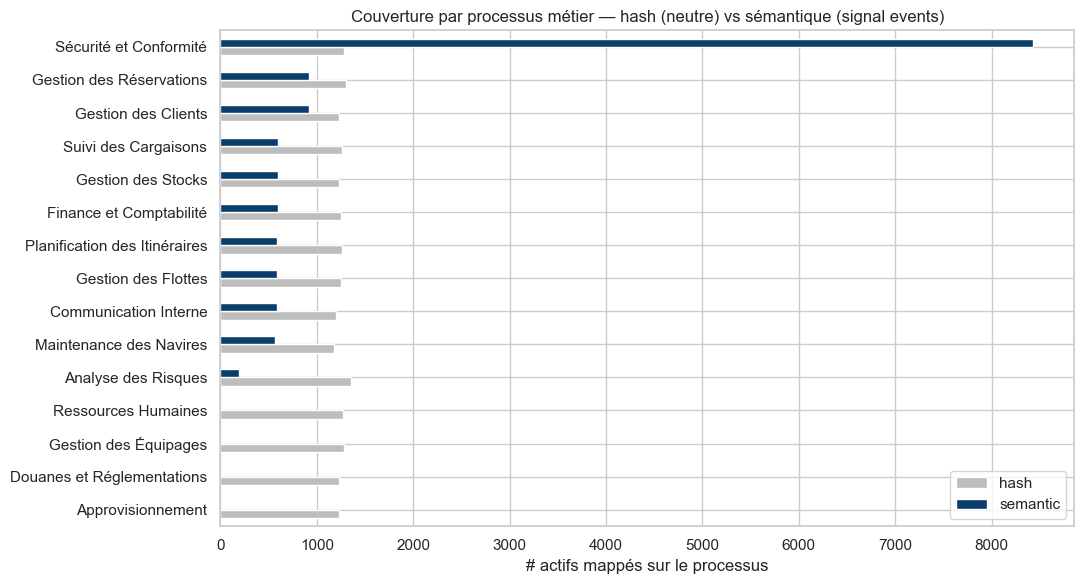


Différences-clefs :
                               hash  semantic  diff
Sécurité et Conformité         1281      8433  7152
Gestion des Clients            1234       915  -319
Gestion des Réservations       1301       915  -386
Communication Interne          1195       582  -613
Maintenance des Navires        1182       562  -620
Gestion des Stocks             1234       596  -638
Finance et Comptabilité        1248       596  -652
Suivi des Cargaisons           1257       596  -661
Gestion des Flottes            1248       582  -666
Planification des Itinéraires  1256       582  -674
Analyse des Risques            1355       195 -1160
Approvisionnement              1226         0 -1226
Douanes et Réglementations     1227         0 -1227
Ressources Humaines            1274         0 -1274
Gestion des Équipages          1277         0 -1277


In [73]:
def coverage_of(mapper, asset_ids):
    rev = mapper.reverse_index(asset_ids)
    return pd.Series({p: len(rev[p]) for p in processes["id"]}, name=mapper.name)

cov_hash = coverage_of(hash_mapper, assets["asset_id"])
cov_sem  = coverage_of(semantic_mapper, assets["asset_id"])
comp = pd.concat([cov_hash, cov_sem], axis=1)
comp.index = comp.index.map(processes.set_index("id")["name"])
comp = comp.sort_values("semantic", ascending=True)

ax = comp.plot(kind="barh", figsize=(11, 6), color=["#bdbdbd", "#0b3d6b"])
ax.set_title("Couverture par processus métier — hash (neutre) vs sémantique (signal events)")
ax.set_xlabel("# actifs mappés sur le processus")
plt.tight_layout(); plt.show()

print("\nDifférences-clefs :")
print(comp.assign(diff=comp["semantic"] - comp["hash"])
          .sort_values("diff", ascending=False)[["hash", "semantic", "diff"]])

### 3d · Fonction d'impact générique (mapper-agnostic)

C'est ici qu'on injectera la **vraie cartographie MOA** :
```python
class MOAMapper(ProcessMapper):
    name = "moa"
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)  # colonnes : asset_id, process_id
        self._m = df.groupby("asset_id")["process_id"].apply(list).to_dict()
    def map_asset(self, asset_id):
        return self._m.get(asset_id, [])

MAPPERS["moa"] = MOAMapper("cartographie_moa.csv")
```
Aucun changement requis ailleurs.

In [74]:
def impact_on_processes(cascade_df, mapper: ProcessMapper):
    rev = mapper.reverse_index(assets["asset_id"])
    rows = []
    for _, row in cascade_df.iterrows():
        for p in mapper.map_asset(row["asset"]):
            rows.append({"process": p, "severity": row["severity"]})
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    agg = (df.groupby("process")
             .agg(n_assets_hit=("severity", "size"),
                   mean_severity=("severity", "mean"))
             .reset_index())
    agg["total_assets"]  = agg["process"].map(lambda p: len(rev[p]) if p in rev else 0)
    agg["coverage_pct"]  = np.where(agg["total_assets"] > 0,
                                       agg["n_assets_hit"] / agg["total_assets"] * 100, 0)
    agg["impact_score"]  = agg["mean_severity"] * agg["coverage_pct"] / 100
    agg["name"]          = agg["process"].map(processes.set_index("id")["name"])
    return agg.sort_values("impact_score", ascending=False)

# Démo : même cascade, deux mappers — diagnostics différents
demo_attack = targets.groupby("source").size().sort_values(ascending=False).index[0]
casc_demo, edges_demo = simulate_attack(demo_attack, depth=4, threshold=0.1)
imp_hash = impact_on_processes(casc_demo, hash_mapper)
imp_sem  = impact_on_processes(casc_demo, semantic_mapper)

print(f"Attaque {demo_attack} — {len(casc_demo)} actifs touchés en cascade\n")
print("⊳ Top 5 processus selon HASH MAPPER :")
print(imp_hash[["name", "n_assets_hit", "coverage_pct", "impact_score"]].head())
print("\n⊳ Top 5 processus selon SEMANTIC MAPPER :")
print(imp_sem[["name", "n_assets_hit", "coverage_pct", "impact_score"]].head())

Attaque CVE-2021-5000 — 357 actifs touchés en cascade

⊳ Top 5 processus selon HASH MAPPER :
                        name  n_assets_hit  coverage_pct  impact_score
2      Communication Interne            55      4.602510      0.023116
7   Gestion des Réservations            64      4.919293      0.022869
5        Gestion des Clients            48      3.889789      0.021106
12       Ressources Humaines            60      4.709576      0.020762
4    Finance et Comptabilité            50      4.006410      0.020148

⊳ Top 5 processus selon SEMANTIC MAPPER :
                      name  n_assets_hit  coverage_pct  impact_score
0      Analyse des Risques            13      6.666667      0.037556
7  Maintenance des Navires            27      4.804270      0.022927
2  Finance et Comptabilité            27      4.530201      0.021705
6       Gestion des Stocks            27      4.530201      0.021705
9     Suivi des Cargaisons            27      4.530201      0.021705


## 4 · Visualisation du graphe de cascade

Plotly affiche le **sous-graphe propagé** : seeds entourés en bleu, nœuds touchés colorés du jaune au rouge selon la sévérité, arêtes effectivement utilisées par la cascade.

In [75]:
def plot_cascade_graph(cascade_df, edges_used, title="Graphe de cascade", max_nodes=200):
    if cascade_df is None or cascade_df.empty:
        print("Pas de cascade à afficher"); return
    top = cascade_df.nlargest(max_nodes, "severity")
    keep = set(top["asset"])
    edg = [(a, b) for a, b in edges_used if a in keep and b in keep]

    H = nx.DiGraph(); H.add_nodes_from(keep); H.add_edges_from(edg)
    pos = nx.spring_layout(H, seed=42, k=1.2/np.sqrt(max(len(H), 1)))

    edge_x, edge_y = [], []
    for a, b in H.edges():
        edge_x += [pos[a][0], pos[b][0], None]
        edge_y += [pos[a][1], pos[b][1], None]
    edge_trace = go.Scatter(x=edge_x, y=edge_y, mode="lines",
                              line=dict(width=0.5, color="#aaa"),
                              hoverinfo="none", showlegend=False)

    sev_map   = dict(zip(top["asset"], top["severity"]))
    seed_set  = set(top.loc[top["seed"], "asset"])
    depth_map = dict(zip(top["asset"], top["depth"]))
    nodes = list(H.nodes())
    node_trace = go.Scatter(
        x=[pos[n][0] for n in nodes], y=[pos[n][1] for n in nodes], mode="markers",
        marker=dict(size=[18 if n in seed_set else 9 for n in nodes],
                     color=[sev_map[n] for n in nodes],
                     colorscale="YlOrRd", cmin=0, cmax=1,
                     line=dict(width=[3 if n in seed_set else 0 for n in nodes],
                                color="#0b3d6b"),
                     colorbar=dict(title="severity", thickness=12)),
        text=[f"{n}<br>severity={sev_map[n]:.3f}<br>depth={depth_map[n]}"
                + ("<br><b>SEED</b>" if n in seed_set else "")
              for n in nodes],
        hoverinfo="text", showlegend=False)
    fig = go.Figure(data=[edge_trace, node_trace],
                     layout=go.Layout(title=title, height=600,
                                       margin=dict(l=10, r=10, t=40, b=10),
                                       xaxis=dict(visible=False),
                                       yaxis=dict(visible=False)))
    fig.show()

plot_cascade_graph(casc_demo, edges_demo,
                    title=f"Cascade — attaque {demo_attack} (top 200 actifs)")

## 5 · Tableau de bord interactif — par attaque

Levers :
- choix d'attaque, profondeur, seuil
- **commutateur de mapper** (`hash` ↔ `semantic`) pour comparer les diagnostics métier en direct

In [76]:
import ipywidgets as W
from IPython.display import display, clear_output

MAPPERS = {"hash": hash_mapper, "semantic": semantic_mapper}

valid_attacks = (targets.merge(attacks, left_on="source", right_on="id")
                          .groupby("id").agg(n_targets=("target", "nunique"),
                                                name=("name", "first"),
                                                severity=("severity", "first"))
                          .sort_values("n_targets", ascending=False))
options = [(f"{idx} — {row['name']} ({row['severity']}, {row['n_targets']} cibles)", idx)
           for idx, row in valid_attacks.head(80).iterrows()]

w_attack    = W.Dropdown(options=options, description="Attaque",
                          layout=W.Layout(width="680px"))
w_depth     = W.IntSlider(value=4, min=1, max=8, step=1, description="Profondeur")
w_threshold = W.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01,
                              description="Seuil", readout_format=".2f")
w_mapper    = W.ToggleButtons(options=["hash", "semantic"], value="semantic",
                                description="Mapper")
w_button    = W.Button(description="▶ Simuler", button_style="primary")
w_output    = W.Output()

def run(_):
    with w_output:
        clear_output(wait=True)
        atk  = w_attack.value
        mapper = MAPPERS[w_mapper.value]
        casc, edg = simulate_attack(atk, depth=w_depth.value, threshold=w_threshold.value)
        if casc is None or casc.empty:
            print("Aucune cible / propagation"); return
        imp = impact_on_processes(casc, mapper)

        print(f"📊  Attaque {atk}  |  Mapper = {mapper.name}")
        print(f"    Cibles initiales : {targets[targets['source']==atk]['target'].nunique()}")
        print(f"    Actifs touchés   : {len(casc):,}")
        print(f"    Sévérité moy.    : {casc['severity'].mean():.3f}")
        print(f"    Profondeur max   : {int(casc['depth'].max())}")
        print(f"    Processus touchés: {len(imp)} / {len(processes)}")

        if not imp.empty:
            fig = px.bar(imp.head(15), x="impact_score", y="name", orientation="h",
                          color="mean_severity", color_continuous_scale="Reds",
                          title=f"Impact par processus métier (mapper = {mapper.name})",
                          hover_data=["n_assets_hit", "total_assets", "coverage_pct"])
            fig.update_layout(height=400, yaxis={"categoryorder": "total ascending"})
            fig.show()
        plot_cascade_graph(casc, edg, title=f"Graphe de cascade — {atk}", max_nodes=150)

w_button.on_click(run)
display(W.VBox([w_attack, W.HBox([w_depth, w_threshold]), W.HBox([w_mapper, w_button]), w_output]))

## 6 · Curseur temporel — rejeu chronologique

Les `events` ont un `timestamp` et une `related_assets`. En les rejouant chronologiquement :
- à la date **T**, on considère tous les événements hostiles (`Attaque Détectée`, `Incident`, `Alerte`) antérieurs à T,
- chacun apporte ses actifs cibles comme **seeds**, avec une sévérité initiale liée à la `severity` de l'événement,
- on lance une cascade fusionnée (max de sévérité) pour mesurer l'état dégradé du SI.

Cela permet de **glisser dans le temps** et de voir le SI se dégrader progressivement.

In [77]:
HOSTILE_TYPES = {"Attaque Détectée", "Incident", "Alerte"}
ev_hostile = events[events["type"].isin(HOSTILE_TYPES)].copy()
ev_hostile["asset_list"] = ev_hostile["related_assets"].fillna("").apply(
    lambda s: [a.strip() for a in s.split(",") if a.strip()])
ev_hostile = ev_hostile.sort_values("timestamp")

SEVERITY_NUM = {"critical": 1.0, "high": 0.8, "medium": 0.5, "low": 0.3}

def cascade_up_to(date, depth=3, threshold=0.1):
    past = ev_hostile[ev_hostile["timestamp"] <= date]
    seed_sev = {}
    for _, ev in past.iterrows():
        s = SEVERITY_NUM.get(ev["severity"], 0.5)
        for a in ev["asset_list"]:
            if a in G_rev and s > seed_sev.get(a, 0):
                seed_sev[a] = s
    if not seed_sev:
        return None, None, past
    merged_sev, merged_dep, merged_edg = {}, {}, []
    for asset, s0 in seed_sev.items():
        sev, dep, edg = simulate_cascade([asset], depth=depth, threshold=threshold,
                                           initial_severity=s0)
        for a, v in sev.items():
            if v > merged_sev.get(a, 0):
                merged_sev[a] = v; merged_dep[a] = dep[a]
        merged_edg.extend(edg)
    casc = pd.DataFrame({"asset": list(merged_sev),
                          "severity": list(merged_sev.values()),
                          "depth":    [merged_dep[a] for a in merged_sev],
                          "seed":     [a in seed_sev for a in merged_sev]})
    return casc, merged_edg, past

print(f"Fenêtre temporelle : {ev_hostile['timestamp'].min()} → {ev_hostile['timestamp'].max()}")
print(f"# événements hostiles : {len(ev_hostile)}")

Fenêtre temporelle : 2025-01-01 04:37:00+00:00 → 2026-01-01 21:23:00+00:00
# événements hostiles : 1208


In [78]:
# Trajectoire cumulative pour situer le curseur
tmin, tmax = ev_hostile["timestamp"].min(), ev_hostile["timestamp"].max()
timeline = pd.date_range(tmin, tmax, periods=40)
rows = []
for t in timeline:
    c, _, p = cascade_up_to(t, depth=3, threshold=0.1)
    rows.append({"date": t, "n_events": len(p),
                  "n_assets_hit": 0 if c is None else len(c),
                  "mean_severity": 0 if c is None else c["severity"].mean()})
traj = pd.DataFrame(rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=traj["date"], y=traj["n_assets_hit"],
                           name="# actifs touchés (cascade)",
                           line=dict(color="#C44E52", width=2)))
fig.add_trace(go.Scatter(x=traj["date"], y=traj["n_events"],
                           name="# événements hostiles cumulés",
                           line=dict(color="#4C72B0", width=2, dash="dot"), yaxis="y2"))
fig.update_layout(title="Dégradation cumulative du SI au fil du temps",
                   xaxis=dict(title="date"),
                   yaxis=dict(title="# actifs touchés", side="left"),
                   yaxis2=dict(title="# événements", overlaying="y", side="right"),
                   height=400, legend=dict(x=0.01, y=0.99))
fig.show()

In [79]:
# Dashboard temporel — curseur de date + commutateur de mapper
t_dates = pd.date_range(tmin, tmax, periods=30).to_pydatetime().tolist()

w_time   = W.SelectionSlider(options=[(d.strftime("%Y-%m-%d"), d) for d in t_dates],
                              value=t_dates[len(t_dates)//2],
                              description="Date T",
                              layout=W.Layout(width="680px"))
w_t_depth  = W.IntSlider(value=3, min=1, max=6, step=1, description="Profondeur")
w_t_thr    = W.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01,
                             description="Seuil", readout_format=".2f")
w_t_mapper = W.ToggleButtons(options=["hash", "semantic"], value="semantic",
                               description="Mapper")
w_t_button = W.Button(description="▶ Rejouer", button_style="primary")
w_t_output = W.Output()

def run_time(_):
    with w_t_output:
        clear_output(wait=True)
        date = pd.Timestamp(w_time.value)
        mapper = MAPPERS[w_t_mapper.value]
        casc, edg, past = cascade_up_to(date, depth=w_t_depth.value, threshold=w_t_thr.value)
        if casc is None or casc.empty:
            print(f"Aucun événement hostile jusqu'au {date.date()}"); return
        imp = impact_on_processes(casc, mapper)

        print(f"🕒  État simulé du SI au {date.strftime('%Y-%m-%d')}  |  Mapper = {mapper.name}")
        print(f"    Événements hostiles cumulés : {len(past):,} / {len(ev_hostile):,}")
        print(f"    Actifs touchés (cascade)    : {len(casc):,} / {G.number_of_nodes():,}")
        print(f"    Sévérité moyenne            : {casc['severity'].mean():.3f}")
        print(f"    Processus métier dégradés   : {len(imp)} / {len(processes)}")

        if not imp.empty:
            fig = px.bar(imp.head(15), x="impact_score", y="name", orientation="h",
                          color="mean_severity", color_continuous_scale="Reds",
                          title=f"Processus métier dégradés au {date.strftime('%Y-%m-%d')}",
                          hover_data=["n_assets_hit", "total_assets", "coverage_pct"])
            fig.update_layout(height=380, yaxis={"categoryorder": "total ascending"})
            fig.show()
        plot_cascade_graph(casc, edg, title=f"Cascade cumulée au {date.strftime('%Y-%m-%d')}",
                            max_nodes=150)

w_t_button.on_click(run_time)
display(W.VBox([
    w_time,
    W.HBox([w_t_depth, w_t_thr]),
    W.HBox([w_t_mapper, w_t_button]),
    w_t_output,
]))

## 8 · Aller plus loin — trois enrichissements composables

Le notebook tel qu'il est répond au brief. On l'enrichit ici avec **trois briques optionnelles** qui rendent la simulation plus crédible. Elles sont **indépendantes** : on peut activer 0, 1, 2 ou 3 d'entre elles.

| Brique | Question résolue |
|---|---|
| **8a · `SyntheticMOAMapper`** | Comment simuler une vraie cartographie SI↔Métier en attendant la MOA ? |
| **8b · Chaînes MITRE ATT&CK** | Comment modéliser une attaque qui *enchaîne* plusieurs étapes (lateral movement) au lieu d'un seul exploit isolé ? |
| **8c · Patchs temporels & recovery** | Comment introduire de la **réparation** dans le rejeu temporel pour que le SI ne se dégrade pas indéfiniment ? |

### 8a · `SyntheticMOAMapper` — cartographie synthétique réaliste

**Idée.** On combine trois signaux pour produire un mapping proche d'une vraie carto MOA :

1. **Position dans le graphe.** Plus un actif a un PageRank élevé (= hub), plus il sert de processus (4-5). Les actifs feuilles sont mono-processus.
2. **Signal sémantique** (du `SemanticMapper`) en priorité quand il existe.
3. **Distribution-cible métier.** On encode qu'une Marine a ~25 % de ses actifs sur la Gestion des Flottes, ~3 % seulement sur les Douanes, etc.

C'est ce mapping qu'on doit considérer comme le **plus crédible** pour des chiffres opérationnels en attendant la vraie carto.

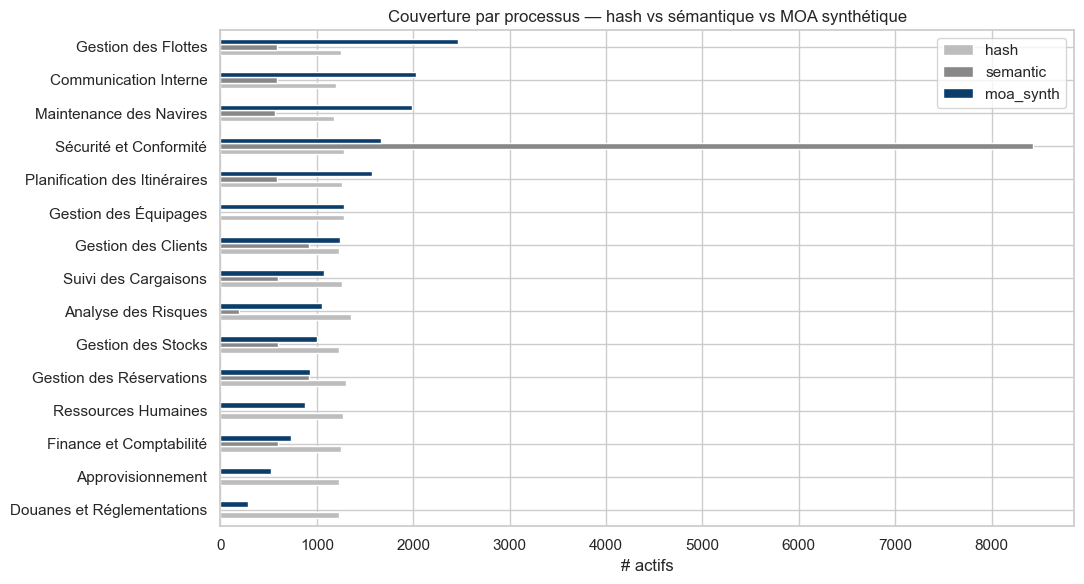


Exemple — IT-00010 :
  hash      → ['process-003', 'process-015']
  semantic  → ['process-015']
  moa_synth → ['process-007']


In [80]:
class SyntheticMOAMapper(ProcessMapper):
    name = "moa_synth"

    # Distribution-cible métier (% des actifs portant chaque processus).
    # Inspirée d'une organisation type Marine : cœur opérationnel sur-représenté.
    TARGET_DISTRIBUTION = {
        "process-007": 0.28,   # Gestion des Flottes        (cœur)
        "process-011": 0.22,   # Maintenance des Navires    (cœur)
        "process-015": 0.20,   # Sécurité et Conformité     (transverse)
        "process-012": 0.18,   # Planification Itinéraires
        "process-003": 0.18,   # Communication Interne      (transverse)
        "process-010": 0.15,   # Gestion des Équipages
        "process-014": 0.12,   # Suivi des Cargaisons
        "process-001": 0.10,   # Analyse des Risques
        "process-013": 0.10,   # Ressources Humaines
        "process-005": 0.08,   # Finance et Comptabilité
        "process-008": 0.07,   # Gestion des Réservations
        "process-006": 0.07,   # Gestion des Clients
        "process-002": 0.06,   # Approvisionnement
        "process-009": 0.05,   # Gestion des Stocks
        "process-004": 0.03,   # Douanes et Réglementations
    }

    def __init__(self, graph, semantic_mapper=None, target_distribution=None, seed=42):
        self.target = target_distribution or self.TARGET_DISTRIBUTION
        rng = np.random.default_rng(seed)
        pr = nx.pagerank(graph, weight="weight")
        pct = pd.Series(pr).rank(pct=True)

        proc_ids = list(self.target.keys())
        weights  = np.array(list(self.target.values()), dtype=float)
        weights /= weights.sum()

        self._mapping = {}
        for asset in graph.nodes():
            p = pct.get(asset, 0.5)
            if   p > 0.95: n = 5      # top hubs = infra partagée
            elif p > 0.80: n = 3
            elif p > 0.40: n = 2
            else:          n = 1      # feuilles = mono-processus

            chosen = set()
            if semantic_mapper is not None:
                sem = [x for x in semantic_mapper.map_asset(asset) if x != "process-015"]
                for x in sem[:n]:
                    chosen.add(x)
            # complète selon la distribution-cible
            tries = 0
            while len(chosen) < n and tries < 30:
                chosen.add(str(rng.choice(proc_ids, p=weights)))
                tries += 1
            self._mapping[asset] = list(chosen)

    def map_asset(self, asset_id):
        return self._mapping.get(asset_id, [])

moa_synth_mapper = SyntheticMOAMapper(G, semantic_mapper)
MAPPERS["moa_synth"] = moa_synth_mapper

# Comparaison des trois mappers
cov_synth = coverage_of(moa_synth_mapper, assets["asset_id"])
comp3 = pd.concat([cov_hash, cov_sem, cov_synth], axis=1)
comp3.columns = ["hash", "semantic", "moa_synth"]
comp3.index = comp3.index.map(processes.set_index("id")["name"])
comp3 = comp3.sort_values("moa_synth", ascending=True)

ax = comp3.plot(kind="barh", figsize=(11, 6),
                color=["#bdbdbd", "#888888", "#0b3d6b"])
ax.set_title("Couverture par processus — hash vs sémantique vs MOA synthétique")
ax.set_xlabel("# actifs")
plt.tight_layout(); plt.show()

print("\nExemple — IT-00010 :")
print(f"  hash      → {hash_mapper.map_asset('IT-00010')}")
print(f"  semantic  → {semantic_mapper.map_asset('IT-00010')}")
print(f"  moa_synth → {moa_synth_mapper.map_asset('IT-00010')}")

### 8a-bis · Comment se construit la carte synthétique — table explicative

Le `SyntheticMOAMapper` combine **trois règles** pour décider quels processus un actif sert :

In [81]:
# Règle 1 — Combien de processus par actif (selon position graphe / PageRank)
tier_rules = pd.DataFrame([
    {"Tier PageRank": "Top 5 % (> 0.95)",      "n_processus": 5,
     "Interprétation": "Super-hubs = infrastructure partagée (AD, DNS, proxy)"},
    {"Tier PageRank": "80 – 95 %",              "n_processus": 3,
     "Interprétation": "Serveurs multi-applicatifs (DB, web, fichiers)"},
    {"Tier PageRank": "40 – 80 %",              "n_processus": 2,
     "Interprétation": "Serveurs spécialisés"},
    {"Tier PageRank": "< 40 % (feuilles)",     "n_processus": 1,
     "Interprétation": "Équipements dédiés mono-processus"},
])
print("📐 RÈGLE 1 — Combien de processus par actif ?\n")
print(tier_rules.to_string(index=False))

# Règle 2 — Distribution-cible métier
proc_name = processes.set_index("id")["name"].to_dict()
dist_rows = [
    ("process-007", 0.28, "Cœur opérationnel : naviguer = mission première"),
    ("process-011", 0.22, "Cœur opérationnel : maintenance industrielle"),
    ("process-015", 0.20, "Transverse : sécurité concerne tout le monde"),
    ("process-012", 0.18, "Soutien opérationnel : préparation des missions"),
    ("process-003", 0.18, "Transverse : communication interne partout"),
    ("process-010", 0.15, "RH opérationnelles : équipages"),
    ("process-014", 0.12, "Cargaisons / logistique"),
    ("process-001", 0.10, "Analyse des risques (transverse)"),
    ("process-013", 0.10, "RH support (paie, mobilité)"),
    ("process-005", 0.08, "Finance & comptabilité"),
    ("process-008", 0.07, "Réservations (peu naval)"),
    ("process-006", 0.07, "Clients (peu naval)"),
    ("process-002", 0.06, "Approvisionnement"),
    ("process-009", 0.05, "Stocks"),
    ("process-004", 0.03, "Douanes (périphérique)"),
]
dist_df = pd.DataFrame([
    {"Processus": proc_name[pid], "Cible": f"{int(pct*100)} %",
     "Justification": just}
    for pid, pct, just in dist_rows])
print("\n📊 RÈGLE 2 — Distribution-cible par processus (% des actifs)\n")
print(dist_df.to_string(index=False))

# Règle 3 — Algorithme
print("""
🔧 RÈGLE 3 — Algorithme d'allocation pour CHAQUE actif

  Étape 1. Lire le tier PageRank de l'actif → détermine n ∈ {1, 2, 3, 5}.
  Étape 2. Lire le signal sémantique (SemanticMapper) → 1er choix de processus
            (sauf process-015 qui est le fallback).
  Étape 3. Si on a < n processus, compléter par tirage pondéré aléatoire
            selon la distribution-cible de la règle 2.
  Étape 4. Mettre en cache. Tout est déterministe (seed=42).

📌 Exemple concret sur 3 actifs :""")
for asset in [pr_s.index[0], "IT-00500", "IT-09999"]:
    tier_p = pd.Series(pr).rank(pct=True).get(asset, 0.5)
    procs = moa_synth_mapper.map_asset(asset)
    names = [proc_name.get(p, p) for p in procs]
    print(f"  • {asset:10s}  percentile PR = {tier_p:.2%}  →  {len(procs)} processus")
    for n in names:
        print(f"        - {n}")

📐 RÈGLE 1 — Combien de processus par actif ?

    Tier PageRank  n_processus                                        Interprétation
 Top 5 % (> 0.95)            5 Super-hubs = infrastructure partagée (AD, DNS, proxy)
        80 – 95 %            3        Serveurs multi-applicatifs (DB, web, fichiers)
        40 – 80 %            2                                  Serveurs spécialisés
< 40 % (feuilles)            1                     Équipements dédiés mono-processus

📊 RÈGLE 2 — Distribution-cible par processus (% des actifs)

                    Processus Cible                                   Justification
          Gestion des Flottes  28 % Cœur opérationnel : naviguer = mission première
      Maintenance des Navires  22 %    Cœur opérationnel : maintenance industrielle
       Sécurité et Conformité  20 %    Transverse : sécurité concerne tout le monde
Planification des Itinéraires  18 % Soutien opérationnel : préparation des missions
        Communication Interne  18 %      Transv

### 8b · Chaînes MITRE ATT&CK — du *single exploit* à la *kill chain*

**Idée.** Dans la vraie vie, un attaquant ne lance pas un exploit isolé : il **enchaîne** des étapes dans un ordre canonique :

```
initial-access → execution → persistence → privilege-escalation
→ defense-evasion → credential-access → discovery → lateral-movement
→ collection → command-and-control → exfiltration → impact
```

On exploite la colonne `tactics` de `nodes_attacks_final.csv` pour rejouer une kill chain :
1. À chaque phase, on **choisit une TTP/CVE** qui correspond à cette tactic.
2. On lance une cascade.
3. Le **seed de la phase suivante** est un actif compromis (= *lateral movement*).
4. La sévérité décroît légèrement à chaque saut (l'attaquant est de plus en plus loin de son entrée).

Résultat : un **scénario d'attaque réaliste** où chaque actif touché peut servir de pivot.

In [82]:
# Ordre canonique de la kill chain MITRE ATT&CK
KILL_CHAIN_ORDER = [
    "initial-access", "execution", "persistence", "privilege-escalation",
    "defense-evasion", "credential-access", "discovery", "lateral-movement",
    "collection", "command-and-control", "exfiltration", "impact",
]

attacks["tactic_list"] = attacks["tactics"].fillna("").apply(
    lambda s: [t.strip() for t in str(s).split(",") if t.strip()])

TACTIC_INDEX = defaultdict(list)
for _, row in attacks.iterrows():
    for t in row["tactic_list"]:
        TACTIC_INDEX[t].append(row["id"])

print("Couverture des tactics par les attaques de la base :")
for t in KILL_CHAIN_ORDER:
    n = len(TACTIC_INDEX[t])
    bar = "█" * (n // 10) if n else "·"
    print(f"  {t:25s} {n:>4} {bar}")

Couverture des tactics par les attaques de la base :
  initial-access             167 ████████████████
  execution                  258 █████████████████████████
  persistence                 72 ███████
  privilege-escalation       174 █████████████████
  defense-evasion             91 █████████
  credential-access            0 ·
  discovery                   98 █████████
  lateral-movement            72 ███████
  collection                   0 ·
  command-and-control          0 ·
  exfiltration                 1 
  impact                      68 ██████


In [83]:
def simulate_attack_chain(initial_seed, n_phases=5, depth=3, threshold=0.1,
                            rng_seed=42, start_phase="initial-access"):
    """Rejoue une kill chain depuis `initial_seed`.
    Retourne (timeline_df, cascade_cumulée_df, edges_used)."""
    rng = np.random.default_rng(rng_seed)
    start_idx = KILL_CHAIN_ORDER.index(start_phase)
    phases = [p for p in KILL_CHAIN_ORDER[start_idx:start_idx+n_phases]
              if TACTIC_INDEX[p]]

    timeline = []
    current_seeds = [initial_seed]
    severity = 1.0
    all_sev, all_dep, all_edg = {}, {}, []
    seeds_cumul = set()

    for phase in phases:
        ttp = str(rng.choice(TACTIC_INDEX[phase]))
        seeds_cumul.update(current_seeds)
        sev_d, dep_d, edg = simulate_cascade(current_seeds, depth=depth,
                                              threshold=threshold,
                                              initial_severity=severity)
        timeline.append({"phase": phase, "ttp": ttp,
                          "seed": current_seeds[0],
                          "n_compromised": len(sev_d),
                          "severity_in": round(severity, 3)})
        for a, v in sev_d.items():
            if v > all_sev.get(a, 0):
                all_sev[a] = v; all_dep[a] = dep_d[a]
        all_edg.extend(edg)
        # lateral movement
        if sev_d:
            current_seeds = [str(rng.choice(list(sev_d.keys())))]
            severity *= 0.9
        else:
            break

    casc = pd.DataFrame({"asset": list(all_sev),
                          "severity": list(all_sev.values()),
                          "depth":    [all_dep[a] for a in all_sev],
                          "seed":     [a in seeds_cumul for a in all_sev]})
    return pd.DataFrame(timeline), casc, all_edg

# Démo : kill chain depuis le hub n°1
hub = pr_s.index[0]
tl, casc_chain, edg_chain = simulate_attack_chain(hub, n_phases=6, rng_seed=7)
print("Timeline de la kill chain :")
print(tl.to_string(index=False))
print(f"\nTotal cumulé : {len(casc_chain):,} actifs compromis sur les {len(tl)} phases")

plot_cascade_graph(casc_chain, edg_chain,
                   title=f"Kill chain MITRE depuis {hub} — {len(tl)} phases enchaînées",
                   max_nodes=200)

Timeline de la kill chain :
               phase           ttp     seed  n_compromised  severity_in
      initial-access CVE-2020-4520 IT-04416             73        1.000
           execution         T6606 IT-00933              9        0.900
         persistence         T7048 IT-09002             52        0.810
privilege-escalation CVE-2025-6270 IT-00703              1        0.729
     defense-evasion         T2340 IT-00703              1        0.656

Total cumulé : 131 actifs compromis sur les 5 phases


### 8c · Patchs temporels & recovery — réversibilité du SI

**Idée.** Aujourd'hui notre rejeu temporel est **monotone croissant** : plus le temps avance, plus le SI est compromis. C'est faux — les vrais SOC appliquent des correctifs et **récupèrent** des actifs.

**Modèle simple.** On génère un **calendrier de patchs** :
- CVE/TTP `critical` : patché 30-90 jours après sa première apparition,
- `high` : 90-180 jours,
- `medium` : 180-365 jours,
- `low` : 365-730 jours.

À la date T, lors du rejeu, on **filtre les seeds** : un actif n'est plus considéré comme compromis si **toutes** les attaques qui l'ont touché ont été patchées avant T.

Résultat : la courbe de dégradation **monte puis redescend** — beaucoup plus réaliste.

Distribution des dates de patch :
count                                   3000
mean     2025-04-30 16:27:52.799999744+00:00
min                2025-01-31 04:37:00+00:00
25%                2025-03-06 04:37:00+00:00
50%                2025-04-12 04:37:00+00:00
75%                2025-06-03 04:37:00+00:00
max                2026-01-01 04:37:00+00:00
Name: patched_at, dtype: object


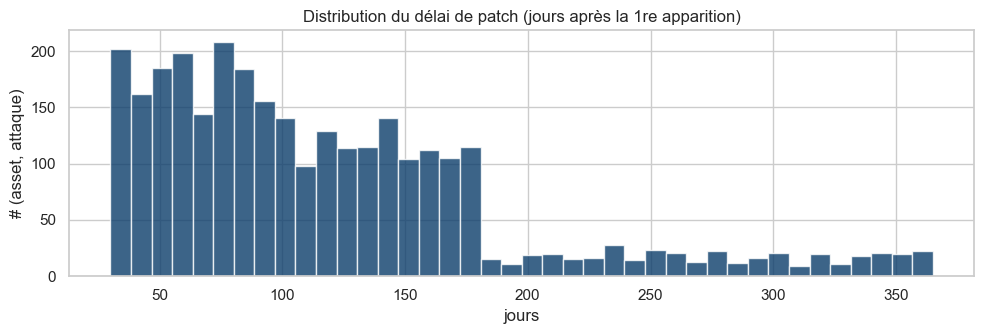

In [84]:
def generate_patch_schedule(targets_df, attacks_df, base_date, seed=42):
    """Pour chaque (asset, attack), génère une date de patch dépendant de la sévérité."""
    rng = np.random.default_rng(seed)
    sev_windows = {"critical": (30, 90), "high": (90, 180),
                   "medium": (180, 365), "low": (365, 730)}
    atk_sev = attacks_df.set_index("id")["severity"].to_dict()
    rows = []
    for _, row in targets_df.iterrows():
        s = atk_sev.get(row["source"], "medium")
        if not isinstance(s, str):
            s = "medium"
        low, high = sev_windows.get(s, (180, 365))
        days = int(rng.integers(low, high + 1))
        rows.append({"asset": row["target"], "attack": row["source"],
                      "patched_at": base_date + pd.Timedelta(days=days)})
    return pd.DataFrame(rows)

base_date = ev_hostile["timestamp"].min()
patch_schedule = generate_patch_schedule(targets, attacks, base_date)
patch_lookup   = patch_schedule.set_index(["asset", "attack"])["patched_at"].to_dict()

print("Distribution des dates de patch :")
print(patch_schedule["patched_at"].describe())

# Histogramme des delays
delays = (patch_schedule["patched_at"] - base_date).dt.days
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(delays, bins=40, color="#0b3d6b", alpha=0.8)
ax.set_title("Distribution du délai de patch (jours après la 1re apparition)")
ax.set_xlabel("jours"); ax.set_ylabel("# (asset, attaque)")
plt.tight_layout(); plt.show()

In [85]:
def parse_id_list(s):
    if pd.isna(s): return []
    return [x.strip() for x in str(s).split(",") if x.strip()]

ev_hostile["attack_list"] = ev_hostile["related_attacks"].apply(parse_id_list)

def cascade_up_to_with_patches(date, depth=3, threshold=0.1):
    """Variante de cascade_up_to qui ignore les seeds patchés à `date`."""
    past = ev_hostile[ev_hostile["timestamp"] <= date]
    seed_sev = {}
    n_patched = 0
    for _, ev in past.iterrows():
        s = SEVERITY_NUM.get(ev["severity"], 0.5)
        for a in ev["asset_list"]:
            if a not in G_rev:
                continue
            atks = ev["attack_list"]
            if atks:
                fully_patched = all(
                    (patch_lookup.get((a, atk)) is not None
                     and patch_lookup[(a, atk)] <= date)
                    for atk in atks)
                if fully_patched:
                    n_patched += 1
                    continue
            if s > seed_sev.get(a, 0):
                seed_sev[a] = s
    if not seed_sev:
        return None, [], past, n_patched
    merged_sev, merged_dep, merged_edg = {}, {}, []
    for asset, s0 in seed_sev.items():
        sev, dep, edg = simulate_cascade([asset], depth=depth, threshold=threshold,
                                          initial_severity=s0)
        for a, v in sev.items():
            if v > merged_sev.get(a, 0):
                merged_sev[a] = v; merged_dep[a] = dep[a]
        merged_edg.extend(edg)
    casc = pd.DataFrame({"asset": list(merged_sev),
                          "severity": list(merged_sev.values()),
                          "depth":    [merged_dep[a] for a in merged_sev],
                          "seed":     [a in seed_sev for a in merged_sev]})
    return casc, merged_edg, past, n_patched

# Trajectoire comparée : sans patch vs avec patch
timeline2 = pd.date_range(ev_hostile["timestamp"].min(),
                          ev_hostile["timestamp"].max() + pd.Timedelta(days=365),
                          periods=50)
rows = []
for t in timeline2:
    c1, _, _      = cascade_up_to(t, depth=3, threshold=0.1)
    c2, _, _, np_ = cascade_up_to_with_patches(t, depth=3, threshold=0.1)
    rows.append({"date": t,
                  "sans_patch": 0 if c1 is None else len(c1),
                  "avec_patch": 0 if c2 is None else len(c2),
                  "n_patched":  np_})
traj2 = pd.DataFrame(rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=traj2["date"], y=traj2["sans_patch"],
                          name="sans patch (monotone)", line=dict(color="#C44E52", width=2)))
fig.add_trace(go.Scatter(x=traj2["date"], y=traj2["avec_patch"],
                          name="avec patch (réversible)", line=dict(color="#55A868", width=2)))
fig.add_trace(go.Scatter(x=traj2["date"], y=traj2["n_patched"],
                          name="# (asset, atk) patchés",
                          line=dict(color="#888", width=1, dash="dot"), yaxis="y2"))
fig.update_layout(title="Dégradation du SI — effet du calendrier de patch",
                   xaxis=dict(title="date"),
                   yaxis=dict(title="# actifs touchés", side="left"),
                   yaxis2=dict(title="# patchs appliqués", overlaying="y", side="right"),
                   height=420, legend=dict(x=0.01, y=0.99))
fig.show()

### 8d · Dashboard combiné — les trois enrichissements en action

Curseur temporel **avec patchs**, sélecteur de mapper (incluant maintenant `moa_synth`), et option pour rejouer une **kill chain MITRE** au lieu d'une attaque simple.

In [86]:
w_time2   = W.SelectionSlider(options=[(d.strftime("%Y-%m-%d"), d) for d in
                                          pd.date_range(ev_hostile["timestamp"].min(),
                                                         ev_hostile["timestamp"].max() + pd.Timedelta(days=365),
                                                         periods=40).to_pydatetime()],
                               description="Date T", layout=W.Layout(width="680px"))
w_t2_depth   = W.IntSlider(value=3, min=1, max=6, step=1, description="Profondeur")
w_t2_thr     = W.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01,
                              description="Seuil", readout_format=".2f")
w_t2_mapper  = W.ToggleButtons(options=list(MAPPERS.keys()), value="moa_synth",
                                description="Mapper")
w_t2_patch   = W.Checkbox(value=True, description="Appliquer les patchs (recovery)")
w_t2_button  = W.Button(description="▶ Rejouer", button_style="primary")
w_t2_output  = W.Output()

def run_time2(_):
    with w_t2_output:
        clear_output(wait=True)
        date = pd.Timestamp(w_time2.value)
        mapper = MAPPERS[w_t2_mapper.value]
        if w_t2_patch.value:
            casc, edg, past, n_pat = cascade_up_to_with_patches(
                date, depth=w_t2_depth.value, threshold=w_t2_thr.value)
            patch_info = f"  |  Patchs effectifs : {n_pat}"
        else:
            casc, edg, past = cascade_up_to(date, depth=w_t2_depth.value,
                                              threshold=w_t2_thr.value)
            patch_info = "  |  Patchs désactivés"
        if casc is None or casc.empty:
            print(f"Aucun événement / tout patché au {date.date()}{patch_info}")
            return
        imp = impact_on_processes(casc, mapper)
        print(f"🕒  État simulé au {date.strftime('%Y-%m-%d')}  |  Mapper = {mapper.name}{patch_info}")
        print(f"    Événements hostiles cumulés : {len(past):,} / {len(ev_hostile):,}")
        print(f"    Actifs touchés (cascade)    : {len(casc):,}")
        print(f"    Processus dégradés          : {len(imp)} / {len(processes)}")
        if not imp.empty:
            fig = px.bar(imp.head(15), x="impact_score", y="name", orientation="h",
                          color="mean_severity", color_continuous_scale="Reds",
                          title=f"Processus dégradés au {date.strftime('%Y-%m-%d')}",
                          hover_data=["n_assets_hit", "total_assets", "coverage_pct"])
            fig.update_layout(height=380, yaxis={"categoryorder": "total ascending"})
            fig.show()
        plot_cascade_graph(casc, edg,
                            title=f"Cascade au {date.strftime('%Y-%m-%d')}", max_nodes=150)

w_t2_button.on_click(run_time2)
display(W.VBox([w_time2,
                 W.HBox([w_t2_depth, w_t2_thr]),
                 W.HBox([w_t2_mapper, w_t2_patch]),
                 w_t2_button, w_t2_output]))

## 10 · Vue décideur — comprendre sans être technique

Les sections 1-8 montrent le moteur. Cette section ajoute la **couche de lecture** pour quelqu'un qui n'a pas le code en tête :

- une fonction de **narration** qui traduit les métriques en phrases françaises ;
- un moteur de **recommandations d'actions** (top actifs à isoler, top processus à protéger) ;
- un **dashboard simplifié** orienté briefing.

### ⚠️ Important — pourquoi les patchs sont activés par défaut ici

Le rejeu temporel **sans modèle de patch** produit une courbe d'actifs touchés *monotone croissante* : visuellement, on a l'impression que **tout reste compromis indéfiniment**. C'est faux dans la vraie vie — les équipes appliquent des correctifs.

Dans cette section, les **patchs sont actifs par défaut**. Si on les désactive (case à décocher), un **avertissement explicite** s'affiche : la vue « sans patch » n'est utile que pour comprendre *l'accumulation théorique*, pas pour piloter.

### 10a · Traduction en français + recommandations d'actions

Deux fonctions :

- `narrative_summary(cascade, mapper, date)` → liste de phrases françaises lisibles.
- `recommend_actions(cascade, mapper)` → top actifs à isoler + top processus à protéger.

In [87]:
def narrative_summary(cascade_df, mapper, date=None, total_assets=None):
    """Traduit une cascade en phrases françaises lisibles par un décideur."""
    if cascade_df is None or cascade_df.empty:
        return ["✅ **Aucun actif compromis** à cette date — le SI est sain."]

    total_assets = total_assets or G.number_of_nodes()
    n_hit = len(cascade_df)
    pct = n_hit / total_assets * 100
    sev_mean = cascade_df["severity"].mean()
    n_severe = int((cascade_df["severity"] >= 0.7).sum())

    imp = impact_on_processes(cascade_df, mapper)
    top_proc = imp.iloc[0] if not imp.empty else None
    crit_proc = imp[imp["coverage_pct"] >= 30] if not imp.empty else imp

    lines = []

    # 1. État général qualitatif
    qualif = "🟥 critique" if pct > 20 else "🟧 préoccupant" if pct > 5 else "🟨 limité"
    lines.append(f"📊 **État général ({qualif})** : {n_hit:,} actifs compromis sur "
                  f"{total_assets:,} ({pct:.1f} % du SI).")

    # 2. Gravité
    if n_severe > 0:
        lines.append(f"🔥 **Gravité** : {n_severe:,} actifs en compromission **sévère** "
                      f"(gravité ≥ 0.7). Gravité moyenne globale : {sev_mean:.2f}.")
    else:
        lines.append(f"⚠️ **Gravité** : compromission modérée (moyenne {sev_mean:.2f}). "
                      "Aucun cas extrême identifié.")

    # 3. Processus le plus exposé
    if top_proc is not None:
        lines.append(f"🎯 **Processus le plus exposé** : « {top_proc['name']} » — "
                      f"{int(top_proc['n_assets_hit'])} de ses {int(top_proc['total_assets'])} "
                      f"actifs touchés ({top_proc['coverage_pct']:.0f} % de son périmètre).")

    # 4. Processus en alerte rouge
    if len(crit_proc) > 0:
        names = ", ".join(crit_proc["name"].head(3))
        lines.append(f"🚨 **Processus en alerte rouge** (> 30 % de leurs actifs touchés) : "
                      f"{len(crit_proc)} processus, dont **{names}**.")
    else:
        lines.append("✅ **Aucun processus** n'est touché à plus de 30 % de son périmètre.")

    # 5. Date
    if date is not None:
        lines.append(f"📅 État simulé au **{pd.Timestamp(date).strftime('%d %B %Y')}**.")

    return lines

# Démo
demo_atk = targets.groupby("source").size().sort_values(ascending=False).index[0]
casc_demo2, edg_demo2 = simulate_attack(demo_atk, depth=4, threshold=0.1)
print(f"=== Démo : attaque {demo_atk} ===\n")
for line in narrative_summary(casc_demo2, moa_synth_mapper):
    print(line)

=== Démo : attaque CVE-2021-5000 ===

📊 **État général (🟨 limité)** : 357 actifs compromis sur 9,855 (3.6 % du SI).
🔥 **Gravité** : 109 actifs en compromission **sévère** (gravité ≥ 0.7). Gravité moyenne globale : 0.48.
🎯 **Processus le plus exposé** : « Douanes et Réglementations » — 17 de ses 287 actifs touchés (6 % de son périmètre).
✅ **Aucun processus** n'est touché à plus de 30 % de son périmètre.


In [88]:
def recommend_actions(cascade_df, mapper, top_n=5):
    """Top N actifs à isoler (priorité = sévérité × centralité) + top N processus à protéger."""
    if cascade_df is None or cascade_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    casc = cascade_df.copy()
    casc["pagerank"] = casc["asset"].map(pr).fillna(0)
    casc["priority"] = casc["severity"] * casc["pagerank"].rank(pct=True)
    top_assets = (casc.nlargest(top_n, "priority")
                   [["asset", "severity", "depth", "pagerank"]]
                   .reset_index(drop=True))

    imp = impact_on_processes(cascade_df, mapper)
    top_procs = (imp.head(top_n)
                  [["name", "n_assets_hit", "total_assets",
                    "coverage_pct", "impact_score"]]
                  .reset_index(drop=True))

    return top_assets, top_procs

ta, tp = recommend_actions(casc_demo2, moa_synth_mapper, top_n=5)
print("🛡️ TOP 5 actifs à isoler en priorité :\n")
print(ta.to_string(index=False))
print("\n📋 TOP 5 processus métier à protéger en priorité :\n")
print(tp.to_string(index=False))

🛡️ TOP 5 actifs à isoler en priorité :

   asset  severity  depth  pagerank
IT-03843      0.88      3  0.000354
IT-06545      0.88      4  0.000343
IT-04255      0.88      2  0.000300
IT-05713      0.88      1  0.000269
IT-07965      0.88      3  0.000258

📋 TOP 5 processus métier à protéger en priorité :

                      name  n_assets_hit  total_assets  coverage_pct  impact_score
Douanes et Réglementations            17           287      5.923345      0.029436
         Approvisionnement            22           524      4.198473      0.024385
        Gestion des Stocks            42          1005      4.179104      0.020954
       Gestion des Clients            50          1240      4.032258      0.019012
  Gestion des Réservations            41           928      4.418103      0.018590


### 10b · Dashboard décideur — briefing au lieu d'analyse

Différences avec le dashboard §8d :

- **Patchs activés par défaut** (case décochable mais avertissement explicite si OFF).
- **Pas de paramètres exotiques** — pas de seuil, pas de profondeur visible : valeurs fixes raisonnables.
- **Sortie en mode briefing** : KPI larges, narration en clair, top actions, et un seul graphique synthétique.

In [89]:
w_d_time = W.SelectionSlider(
    options=[(d.strftime("%d %b %Y"), d) for d in
             pd.date_range(ev_hostile["timestamp"].min(),
                            ev_hostile["timestamp"].max() + pd.Timedelta(days=365),
                            periods=40).to_pydatetime()],
    description="Date", layout=W.Layout(width="650px"))
w_d_patch  = W.Checkbox(value=True, description="🟢 Patchs appliqués (vue réaliste)")
w_d_button = W.Button(description="▶ Briefing", button_style="primary",
                       layout=W.Layout(width="180px"))
w_d_output = W.Output()

def run_decision(_):
    with w_d_output:
        clear_output(wait=True)
        date = pd.Timestamp(w_d_time.value)

        if w_d_patch.value:
            casc, edg, past, n_pat = cascade_up_to_with_patches(
                date, depth=3, threshold=0.1)
            header = (f"✅ Vue réaliste — {n_pat:,} patchs effectifs cumulés "
                      f"au {date.strftime('%d/%m/%Y')}")
        else:
            casc, edg, past = cascade_up_to(date, depth=3, threshold=0.1)
            header = ("🚨 ⚠️  VUE SANS PATCH — IRRÉALISTE À LONG TERME  ⚠️ 🚨\n"
                      "    Cette vue suppose qu'aucun correctif n'est jamais appliqué.\n"
                      "    Utile pour comprendre l'accumulation théorique uniquement.")

        print("═" * 76)
        print(f"  BRIEFING SI · {date.strftime('%d %B %Y')}".upper())
        print("═" * 76)
        print(header)
        print()

        for line in narrative_summary(casc, moa_synth_mapper, date=date):
            print("  " + line)

        if casc is None or casc.empty:
            return

        ta, tp = recommend_actions(casc, moa_synth_mapper, top_n=5)
        print()
        print("─" * 76)
        print("  🎯 ACTIONS RECOMMANDÉES")
        print("─" * 76)
        print("\n  🛡️ TOP 5 actifs à isoler immédiatement :")
        for _, r in ta.iterrows():
            print(f"     • {r['asset']:12s}  gravité {r['severity']:.2f}  "
                   f"profondeur {int(r['depth'])}")
        print("\n  📋 TOP 5 processus à protéger :")
        for _, r in tp.iterrows():
            print(f"     • {r['name']:30s}  {r['coverage_pct']:5.1f} %  "
                   f"({int(r['n_assets_hit'])}/{int(r['total_assets'])} actifs)")

        imp = impact_on_processes(casc, moa_synth_mapper)
        if not imp.empty:
            fig = px.bar(imp.head(10), x="impact_score", y="name", orientation="h",
                          color="mean_severity", color_continuous_scale="Reds",
                          title="Processus métier dégradés (top 10)",
                          hover_data=["n_assets_hit", "total_assets", "coverage_pct"])
            fig.update_layout(height=380, yaxis={"categoryorder": "total ascending"})
            fig.show()

w_d_button.on_click(run_decision)
display(W.VBox([w_d_time, W.HBox([w_d_patch, w_d_button]), w_d_output]))

### 10c · Trajectoire pédagogique — pourquoi le « sans patch » n'a pas de sens

Le graphique ci-dessous superpose les deux modèles, **avec une annotation explicite** :

- 🔴 **Sans patch** : courbe qui monte indéfiniment → représente la **menace brute** qu'on accumulerait si on ne faisait rien.
- 🟢 **Avec patch (réaliste)** : courbe qui monte **puis redescend** → représente la **vraie posture** après remédiation.

L'écart entre les deux courbes mesure la **valeur opérationnelle du SOC** : c'est tout ce que l'équipe sécurité empêche de devenir un incident long.

In [90]:
# Trajectoire pédagogique avec annotations
timeline3 = pd.date_range(ev_hostile["timestamp"].min(),
                           ev_hostile["timestamp"].max() + pd.Timedelta(days=365),
                           periods=50)
rows3 = []
for t in timeline3:
    c1, _, _      = cascade_up_to(t, depth=3, threshold=0.1)
    c2, _, _, np_ = cascade_up_to_with_patches(t, depth=3, threshold=0.1)
    rows3.append({"date": t,
                   "sans_patch": 0 if c1 is None else len(c1),
                   "avec_patch": 0 if c2 is None else len(c2)})
traj3 = pd.DataFrame(rows3)

fig = go.Figure()
# Sans patch (théorique)
fig.add_trace(go.Scatter(x=traj3["date"], y=traj3["sans_patch"],
                           name="🔴 Sans patch — menace brute (irréaliste)",
                           line=dict(color="#C44E52", width=3),
                           fill="tozeroy", fillcolor="rgba(196,78,82,0.10)"))
# Avec patch (réaliste)
fig.add_trace(go.Scatter(x=traj3["date"], y=traj3["avec_patch"],
                           name="🟢 Avec patch — posture réelle après remédiation",
                           line=dict(color="#55A868", width=3),
                           fill="tozeroy", fillcolor="rgba(85,168,104,0.20)"))

# Annotation : zone d'écart = valeur SOC
peak_idx = traj3["sans_patch"].idxmax()
fig.add_annotation(x=traj3.loc[peak_idx, "date"],
                    y=(traj3.loc[peak_idx, "sans_patch"] +
                       traj3.loc[peak_idx, "avec_patch"]) / 2,
                    text="↕ Écart = valeur du SOC<br>(incidents évités par patching)",
                    showarrow=True, arrowhead=2, ax=80, ay=-30,
                    bgcolor="white", bordercolor="#0b3d6b", borderwidth=1,
                    font=dict(size=11, color="#0b3d6b"))

fig.update_layout(
    title="Dégradation du SI dans le temps — sans patch (irréaliste) vs avec patch (réaliste)",
    xaxis=dict(title="date"),
    yaxis=dict(title="# actifs compromis"),
    height=460, legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.9)"),
    annotations=[dict(text="⚠️ La courbe rouge n'a de sens que pour comprendre "
                            "la menace brute — la réalité opérationnelle, c'est la verte.",
                       x=0.5, y=-0.18, xref="paper", yref="paper",
                       showarrow=False, font=dict(size=10, color="#666"))],
    margin=dict(b=80))
fig.show()

## 12 · Sélection par fenêtre de dates (range slider)

Jusqu'ici, le rejeu temporel **partait toujours du début** du dataset (1ᵉʳ janvier). Pour analyser une **campagne d'attaque précise** ou une **période spécifique**, on ajoute deux fonctions qui prennent une **fenêtre [date_from, date_to]** :

- `cascade_between(date_from, date_to)` — modèle simple (sans patch).
- `cascade_between_with_patches(date_from, date_to)` — modèle réaliste avec recovery.

Les dashboards ci-dessous utilisent maintenant un **`SelectionRangeSlider`** (à 2 poignées) au lieu d'un slider simple.

In [91]:
def cascade_between(date_from, date_to, depth=3, threshold=0.1):
    """Cascade sur la fenêtre [date_from, date_to] uniquement."""
    past = ev_hostile[(ev_hostile["timestamp"] >= pd.Timestamp(date_from)) &
                       (ev_hostile["timestamp"] <= pd.Timestamp(date_to))]
    seed_sev = {}
    for _, ev in past.iterrows():
        s = SEVERITY_NUM.get(ev["severity"], 0.5)
        for a in ev["asset_list"]:
            if a in G_rev and s > seed_sev.get(a, 0):
                seed_sev[a] = s
    if not seed_sev:
        return None, [], past
    merged_sev, merged_dep, merged_edg = {}, {}, []
    for asset, s0 in seed_sev.items():
        sev, dep, edg = simulate_cascade([asset], depth=depth, threshold=threshold,
                                           initial_severity=s0)
        for a, v in sev.items():
            if v > merged_sev.get(a, 0):
                merged_sev[a] = v; merged_dep[a] = dep[a]
        merged_edg.extend(edg)
    casc = pd.DataFrame({"asset": list(merged_sev),
                          "severity": list(merged_sev.values()),
                          "depth":    [merged_dep[a] for a in merged_sev],
                          "seed":     [a in seed_sev for a in merged_sev]})
    return casc, merged_edg, past

def cascade_between_with_patches(date_from, date_to, depth=3, threshold=0.1):
    """Idem mais en appliquant les patchs effectifs avant date_to."""
    past = ev_hostile[(ev_hostile["timestamp"] >= pd.Timestamp(date_from)) &
                       (ev_hostile["timestamp"] <= pd.Timestamp(date_to))]
    seed_sev = {}
    n_patched = 0
    for _, ev in past.iterrows():
        s = SEVERITY_NUM.get(ev["severity"], 0.5)
        for a in ev["asset_list"]:
            if a not in G_rev:
                continue
            atks = ev["attack_list"]
            if atks:
                fully_patched = all(
                    (patch_lookup.get((a, atk)) is not None
                     and patch_lookup[(a, atk)] <= pd.Timestamp(date_to))
                    for atk in atks)
                if fully_patched:
                    n_patched += 1
                    continue
            if s > seed_sev.get(a, 0):
                seed_sev[a] = s
    if not seed_sev:
        return None, [], past, n_patched
    merged_sev, merged_dep, merged_edg = {}, {}, []
    for asset, s0 in seed_sev.items():
        sev, dep, edg = simulate_cascade([asset], depth=depth, threshold=threshold,
                                           initial_severity=s0)
        for a, v in sev.items():
            if v > merged_sev.get(a, 0):
                merged_sev[a] = v; merged_dep[a] = dep[a]
        merged_edg.extend(edg)
    casc = pd.DataFrame({"asset": list(merged_sev),
                          "severity": list(merged_sev.values()),
                          "depth":    [merged_dep[a] for a in merged_sev],
                          "seed":     [a in seed_sev for a in merged_sev]})
    return casc, merged_edg, past, n_patched

# Démo
d1 = ev_hostile["timestamp"].quantile(0.3)
d2 = ev_hostile["timestamp"].quantile(0.7)
c, _, p, n_pat = cascade_between_with_patches(d1, d2)
print(f"Fenêtre : {d1.date()} → {d2.date()}")
print(f"  Événements hostiles dans la fenêtre : {len(p):,}")
print(f"  Actifs compromis (cascade)          : {0 if c is None else len(c):,}")
print(f"  Patchs effectifs                    : {n_pat}")

Fenêtre : 2025-04-30 → 2025-09-21
  Événements hostiles dans la fenêtre : 482
  Actifs compromis (cascade)          : 5,283
  Patchs effectifs                    : 1


In [92]:
# Dashboard décideur — version range slider (sélection de fenêtre)
date_options = [(d.strftime("%d %b %Y"), d) for d in
                pd.date_range(ev_hostile["timestamp"].min(),
                               ev_hostile["timestamp"].max() + pd.Timedelta(days=365),
                               periods=40).to_pydatetime()]

w_range = W.SelectionRangeSlider(
    options=date_options,
    index=(0, len(date_options)//2),
    description="Fenêtre",
    layout=W.Layout(width="700px"),
    style={"description_width": "80px"})
w_r_patch  = W.Checkbox(value=True, description="🟢 Patchs appliqués (vue réaliste)")
w_r_button = W.Button(description="▶ Briefing fenêtre",
                       button_style="primary", layout=W.Layout(width="180px"))
w_r_output = W.Output()

def run_range(_):
    with w_r_output:
        clear_output(wait=True)
        date_from, date_to = w_range.value
        date_from = pd.Timestamp(date_from)
        date_to   = pd.Timestamp(date_to)

        if w_r_patch.value:
            casc, edg, past, n_pat = cascade_between_with_patches(
                date_from, date_to, depth=3, threshold=0.1)
            header = (f"✅ Vue réaliste — {n_pat:,} patchs effectifs sur la fenêtre "
                      f"({date_from.strftime('%d/%m/%Y')} → {date_to.strftime('%d/%m/%Y')})")
        else:
            casc, edg, past = cascade_between(
                date_from, date_to, depth=3, threshold=0.1)
            n_pat = 0
            header = ("🚨 ⚠️  VUE SANS PATCH — IRRÉALISTE À LONG TERME  ⚠️ 🚨\n"
                      "    Utile pour comprendre la menace brute uniquement.")

        print("═" * 76)
        print(f"  BRIEFING SI · FENÊTRE {date_from.strftime('%d %b %Y')} → {date_to.strftime('%d %b %Y')}".upper())
        print("═" * 76)
        print(header)
        print(f"\n  📅 Durée de fenêtre : {(date_to - date_from).days} jours")
        print(f"  📨 Événements hostiles dans la fenêtre : {len(past):,} / {len(ev_hostile):,}")
        print()

        for line in narrative_summary(casc, moa_synth_mapper, date=date_to):
            print("  " + line)

        if casc is None or casc.empty:
            return

        ta, tp = recommend_actions(casc, moa_synth_mapper, top_n=5)
        print()
        print("─" * 76)
        print("  🎯 ACTIONS RECOMMANDÉES")
        print("─" * 76)
        print("\n  🛡️ TOP 5 actifs à isoler :")
        for _, r in ta.iterrows():
            print(f"     • {r['asset']:12s}  gravité {r['severity']:.2f}  "
                   f"profondeur {int(r['depth'])}")
        print("\n  📋 TOP 5 processus à protéger :")
        for _, r in tp.iterrows():
            print(f"     • {r['name']:30s}  {r['coverage_pct']:5.1f} %  "
                   f"({int(r['n_assets_hit'])}/{int(r['total_assets'])} actifs)")

        imp = impact_on_processes(casc, moa_synth_mapper)
        if not imp.empty:
            fig = px.bar(imp.head(10), x="impact_score", y="name", orientation="h",
                          color="mean_severity", color_continuous_scale="Reds",
                          title=f"Processus métier dégradés (fenêtre {date_from.date()} → {date_to.date()})",
                          hover_data=["n_assets_hit", "total_assets", "coverage_pct"])
            fig.update_layout(height=380, yaxis={"categoryorder": "total ascending"})
            fig.show()

w_r_button.on_click(run_range)
display(W.VBox([w_range, W.HBox([w_r_patch, w_r_button]), w_r_output]))

## 11 · Synthèse finale

| Brief | Réponse implémentée |
|---|---|
| Généraliser les traitements précédents | Graphe orienté pondéré (10k nœuds / 20k arêtes) + interface `ProcessMapper` pluggable |
| Simuler l'impact en cascade automatiquement | `simulate_cascade` + `simulate_attack` + `cascade_up_to(date)` + `simulate_attack_chain` |
| Identifier les processus métier affectés | `impact_on_processes(cascade, mapper)` — agnostique au mapper |
| Tableau de bord interactif | §5 par attaque · §6 curseur temporel · §8d analyste · §10b **briefing décideur** |

### Couches d'utilisation
- **§1-7 · Couche analyste** — exploration libre du graphe et des cascades.
- **§8 · Couche réalisme** — kill chain MITRE, mapper synthétique réaliste, modèle de patch.
- **§10 · Couche décideur** — narration en français, recommandations d'actions, dashboard sans paramètre exotique.

### Quatre mappers disponibles, une seule interface
- `HashMapper` — baseline neutre.
- `SemanticMapper` — signal métier via dictionnaire éditable.
- `SyntheticMOAMapper` — combine PageRank + sémantique + distribution-cible métier.
- `MOAMapper` (futur) — 10 lignes de code dès que la cartographie SI/MOA est disponible.

→ Voir `EXPLICATIONS_GRAPHE.md` (le code) et `EXPLICATIONS_DONNEES.md` (les données) pour une explication pas-à-pas.